# Name: Danish Zaheer
# Roll no: 25280092

## 1. Zero-Shot Classification on STL-10

In [2]:
# Imports all libraries used across the CLIP notebook.
# Keeps model loading, datasets, plotting, and alignment tools available.
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import STL10
from scipy.linalg import orthogonal_procrustes
from sklearn.manifold import TSNE
from tqdm.auto import tqdm
import clip

c:\Users\DanishZaheer\anaconda3\envs\ATML\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Sets folders and selects the available GPU or CPU device.
# Creates local directories for model weights, data, and report figures.
BASE_DIR = Path.cwd()
MODEL_DIR = BASE_DIR / "Download_model"
DATA_DIR = BASE_DIR.parent / "Data" / "stl10_data"
MODEL_DIR.mkdir(parents=True,exist_ok=True)
DATA_DIR.mkdir(parents=True,exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Current notebook directory :", BASE_DIR)
print("Model directory            :", MODEL_DIR)
print("Dataset directory          :", DATA_DIR)
print("Dataset folder exists      :", DATA_DIR.exists())
print("Device                     :", device)
if torch.cuda.is_available():
    print("GPU                        :", torch.cuda.get_device_name(0))

Current notebook directory : c:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_0\Task-3
Model directory            : c:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_0\Task-3\Download_model
Dataset directory          : c:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_0\Data\stl10_data
Dataset folder exists      : True
Device                     : cuda
GPU                        : NVIDIA GeForce RTX 3060 Laptop GPU


In [4]:
# Loads OpenAI CLIP with the selected model name.
# Stores model weights in the local download folder.
MODEL_NAME = "ViT-B/32"
model, preprocess = clip.load(MODEL_NAME,device=device,jit=False,download_root=str(MODEL_DIR))
model.eval()
print(f"Loaded model: {MODEL_NAME}")
print(f"Device: {device}")
print(f"Model files saved in: {MODEL_DIR}")
print("\nContents of Download_model:")
for file in MODEL_DIR.iterdir():
    print(" -", file.name)

Loaded model: ViT-B/32
Device: cuda
Model files saved in: c:\Users\DanishZaheer\Desktop\LUMS\Semester_3\ATML\PA_0\Task-3\Download_model

Contents of Download_model:
 - ViT-B-32.pt


In [5]:
# Downloads and prepares the STL-10 test dataset.
# Stores class names for zero-shot evaluation.
test_dataset = STL10(root=str(DATA_DIR),split="test",download=True,transform=preprocess)
class_names = test_dataset.classes
print("Number of test images:", len(test_dataset))
print("Number of classes:", len(class_names))
print("Classes:")
print(class_names)

Number of test images: 8000
Number of classes: 10
Classes:
['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [6]:
# Creates the STL-10 test DataLoader.
# Uses batches for complete test-set feature extraction.
BATCH_SIZE = 128
test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=0,pin_memory=(device == "cuda"))
print("Number of batches:", len(test_loader))
print("Batch size:", BATCH_SIZE)

Number of batches: 63
Batch size: 128


In [7]:
# Extracts normalized CLIP image features for all test images.
# Stores features and labels on CPU for later comparisons.
all_image_features = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Extracting CLIP image features"):
        images = images.to(device)
        image_features = model.encode_image(images)
        image_features = image_features.float()
        image_features = image_features / image_features.norm(dim=-1,keepdim=True)
        all_image_features.append(image_features.cpu())
        all_labels.append(labels.cpu())

image_features = torch.cat(all_image_features, dim=0)
true_labels = torch.cat(all_labels, dim=0)
print("Image feature shape:", image_features.shape)
print("Label shape:", true_labels.shape)

Extracting CLIP image features: 100%|██████████| 63/63 [00:14<00:00,  4.47it/s]

Image feature shape: torch.Size([8000, 512])
Label shape: torch.Size([8000])


In [8]:
# Defines the prompt-generation strategies for STL-10 classes.
# Keeps prompts class-aware so zero-shot accuracy is evaluated correctly.
def generate_prompts(class_name, strategy):
    if strategy == "plain":
        return [class_name]
    elif strategy == "photo":
        return [f"a photo of a {class_name}."]
    elif strategy == "descriptive":
        return [
            f"a photo of orange {class_name}.",
            f"a {class_name} in loaf position.",
            f"a image of yawning {class_name}."]
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

for strategy in ["plain","photo","descriptive"]:
    print(f"\n{strategy.upper()} prompts:")
    print(generate_prompts("cat",strategy))


PLAIN prompts:
['cat']

PHOTO prompts:
['a photo of a cat.']

DESCRIPTIVE prompts:
['a photo of orange cat.', 'a cat in loaf position.', 'a image of yawning cat.']


In [9]:
# Defines CLIP text-feature creation for each prompt strategy.
# Averages and normalizes prompt embeddings per class.
@torch.no_grad()
def create_text_features(class_names, strategy):
    class_features = []

    for class_name in class_names:
        prompts = generate_prompts(class_name,strategy)
        text_tokens = clip.tokenize(prompts).to(device)
        text_features = model.encode_text(text_tokens)
        text_features = text_features.float()
        text_features = text_features / text_features.norm(dim=-1,keepdim=True)
        class_feature = text_features.mean(dim=0)
        class_feature = class_feature / class_feature.norm()
        class_features.append(class_feature)

    class_features = torch.stack(class_features)
    return class_features.cpu()

In [10]:
# Defines the zero-shot classification evaluation function.
# Compares image and text embeddings using cosine similarity.
def evaluate_zero_shot(image_features, true_labels, class_names, strategy):
    text_features = create_text_features(class_names,strategy)
    similarity = image_features @ text_features.T
    predictions = similarity.argmax(dim=1)
    correct = (predictions == true_labels).sum().item()
    total = len(true_labels)
    accuracy = 100.0 * correct / total
    return accuracy, predictions, similarity

In [11]:
# Evaluates all three prompting strategies on STL-10.
# Stores accuracies and predictions for comparison.
strategies = ["plain","photo","descriptive"]
results = {}
all_predictions = {}

for strategy in strategies:
    print(f"\nEvaluating strategy: {strategy}")
    accuracy, predictions, similarity = evaluate_zero_shot(image_features=image_features,true_labels=true_labels,class_names=class_names,strategy=strategy)
    results[strategy] = accuracy
    all_predictions[strategy] = predictions
    print(f"Accuracy: {accuracy:.2f}%")


Evaluating strategy: plain
Accuracy: 96.26%

Evaluating strategy: photo
Accuracy: 97.31%

Evaluating strategy: descriptive
Accuracy: 94.88%


In [12]:
# Creates a table of zero-shot accuracy results.
# Compares plain, prompted, and descriptive prompt strategies.
results_df = pd.DataFrame({
    "Prompting Strategy": [
        "Plain labels",
        "Prompted text",
        "Descriptive prompt ensemble"],
    "Accuracy (%)": [
        results["plain"],
        results["photo"],
        results["descriptive"]
    ]})

results_df

,Prompting Strategy,Accuracy (%)
0,Plain labels,96.2625
1,Prompted text,97.3125
2,Descriptive prompt ensemble,94.8750


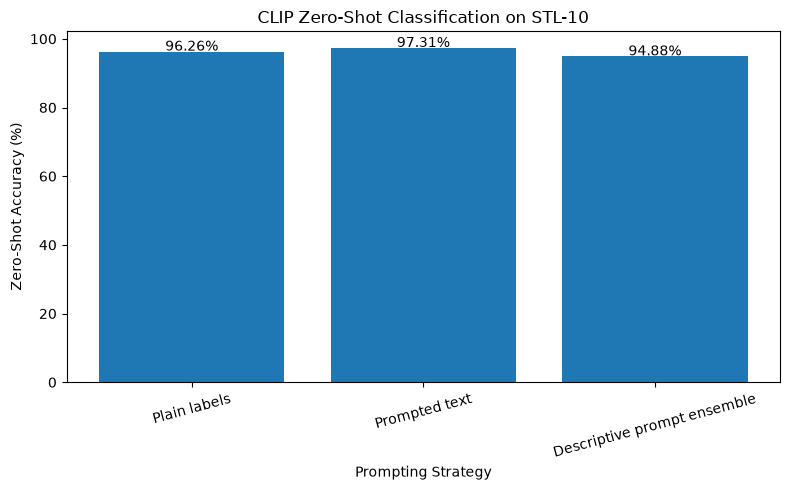

In [13]:
# Plots the zero-shot accuracy comparison.
# Shows performance differences across prompt strategies.
plt.figure(figsize=(8, 5))
bars = plt.bar(results_df["Prompting Strategy"],results_df["Accuracy (%)"])
plt.ylabel("Zero-Shot Accuracy (%)")
plt.xlabel("Prompting Strategy")
plt.title("CLIP Zero-Shot Classification on STL-10")
plt.xticks(rotation=15)

for bar, value in zip(bars, results_df["Accuracy (%)"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{value:.2f}%",
        ha="center")
    
plt.tight_layout()
plt.show()

In [14]:
# Prints the final zero-shot classification summary.
# Reports the best prompt strategy and its accuracy.
print("=" * 60)
print("CLIP ZERO-SHOT CLASSIFICATION Accuracy on STL-10")
print("=" * 60)
print(f"Model: {MODEL_NAME}")
print(f"Number of test images: {len(test_dataset)}")
print("\nPrompting strategy results:")

for strategy, accuracy in results.items():
    print(f"{strategy:15s}: {accuracy:.2f}%")
best_strategy = max(results, key=results.get)

print("\nBest strategy:")
print(
    f"{best_strategy} "
    f"({results[best_strategy]:.2f}%)"
)

CLIP ZERO-SHOT CLASSIFICATION Accuracy on STL-10
Model: ViT-B/32
Number of test images: 8000

Prompting strategy results:
plain          : 96.26%
photo          : 97.31%
descriptive    : 94.88%

Best strategy:
photo (97.31%)


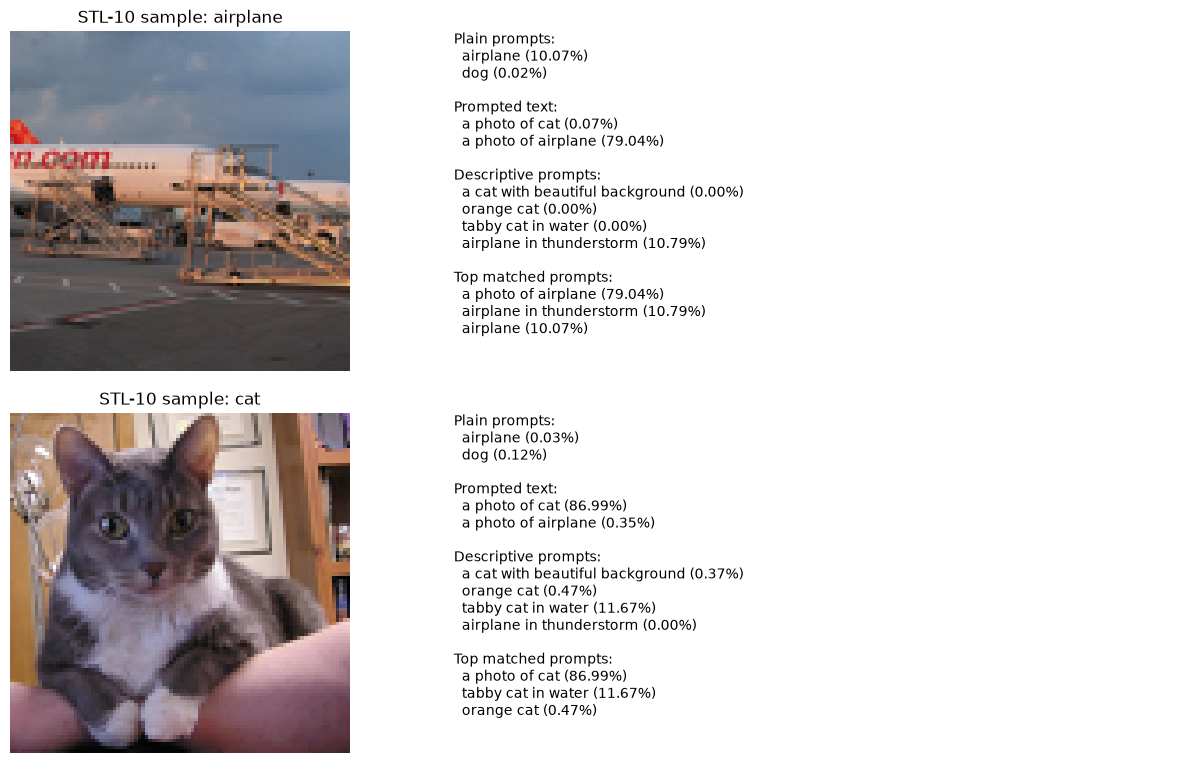

In [15]:
# Visualizes selected STL-10 images with custom CLIP prompt examples.
# Shows how image embeddings match plain, photo-style, and descriptive prompts.
display_dataset = STL10(root=str(DATA_DIR),split="test",download=False,transform=None)
visual_classes = ["airplane","cat"]
visual_indices = []

for target_class in visual_classes:
    target_id = class_names.index(target_class)

    for index in range(len(display_dataset)):
        _, label = display_dataset[index]
        if label == target_id:
            visual_indices.append(index)
            break

report_prompt_groups = {
    "Plain prompts": ["airplane","dog"],
    "Prompted text": ["a photo of cat","a photo of airplane"],
    "Descriptive prompts": ["a cat with beautiful background","orange cat","tabby cat in water","airplane in thunderstorm"]}

report_prompts = []
for prompt_list in report_prompt_groups.values():
    report_prompts.extend(prompt_list)
with torch.no_grad():
    prompt_tokens = clip.tokenize(report_prompts).to(device)
    prompt_features = model.encode_text(prompt_tokens).float()
    prompt_features = prompt_features / prompt_features.norm(dim=-1,keepdim=True)

fig, axes = plt.subplots(len(visual_indices),2,figsize=(14,4 * len(visual_indices)))
if len(visual_indices) == 1:
    axes = [axes]

for row, sample_index in enumerate(visual_indices):
    image, label = display_dataset[sample_index]
    true_class = class_names[label]
    image_tensor = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        sample_image_feature = model.encode_image(image_tensor).float()
        sample_image_feature = sample_image_feature / sample_image_feature.norm(dim=-1,keepdim=True)
        prompt_scores = (100.0 * sample_image_feature @ prompt_features.T).softmax(dim=-1).squeeze(0)
    top_scores, top_indices = prompt_scores.topk(3)
    axes[row][0].imshow(image)
    axes[row][0].set_title(f"STL-10 sample: {true_class}")
    axes[row][0].axis("off")
    text_lines = []

    for group_name, prompt_list in report_prompt_groups.items():
        text_lines.append(group_name + ":")

        for prompt in prompt_list:
            prompt_index = report_prompts.index(prompt)
            text_lines.append(f"  {prompt} ({prompt_scores[prompt_index].item() * 100:.2f}%)")
        text_lines.append("")
    text_lines.append("Top matched prompts:")

    for score, prompt_index in zip(top_scores,top_indices):
        text_lines.append(f"  {report_prompts[prompt_index.item()]} ({score.item() * 100:.2f}%)")
    axes[row][1].axis("off")
    axes[row][1].text(0,1,"\n".join(text_lines),fontsize=10,va="top")

plt.tight_layout()
plt.show()

## 2. Exploring the Modality Gap

In [16]:
# Selects a stratified subset for modality-gap analysis.
# Uses 8 STL-10 samples from each class for balanced visualization.
NUM_SAMPLES = 80
RANDOM_SEED = 42
samples_per_class = NUM_SAMPLES // len(class_names)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
class_to_indices = {class_id: [] for class_id in range(len(class_names))}

for index in range(len(test_dataset)):
    _, label = test_dataset[index]
    class_to_indices[label].append(index)

selected_indices = []
for class_id in range(len(class_names)):
    class_indices = np.array(class_to_indices[class_id])
    chosen_indices = np.random.choice(class_indices,size=samples_per_class,replace=False)
    selected_indices.extend(chosen_indices.tolist())

selected_indices = np.array(selected_indices)
np.random.shuffle(selected_indices)

selected_labels = []
for index in selected_indices:
    _, label = test_dataset[index]
    selected_labels.append(label)

selected_class_counts = pd.Series(selected_labels).value_counts().sort_index()
print("Number of selected samples:", len(selected_indices))
print("Samples per class:", samples_per_class)
print("Class counts:")

for class_id, count in selected_class_counts.items():
    print(f"{class_names[class_id]}: {count}")

Number of selected samples: 80
Samples per class: 8
Class counts:
airplane: 8
bird: 8
car: 8
cat: 8
deer: 8
dog: 8
horse: 8
monkey: 8
ship: 8
truck: 8


In [17]:
# Extracts paired raw image and text embeddings.
# Stores labels, class names, and prompts for the selected subset.
raw_image_embeddings = []
raw_text_embeddings = []
sample_labels = []
sample_class_names = []
sample_prompts = []

with torch.no_grad():
    for idx in tqdm(selected_indices, desc="Extracting image/text embeddings"):
        image_tensor, label = test_dataset[idx]
        class_name = class_names[label]
        article = "an" if class_name[0].lower() in "aeiou" else "a"
        prompt = f"a photo of {article} {class_name}."
        image_input = image_tensor.unsqueeze(0).to(device)
        image_feature = model.encode_image(image_input)
        image_feature = image_feature.float()
        text_tokens = clip.tokenize([prompt]).to(device)
        text_feature = model.encode_text(text_tokens)
        text_feature = text_feature.float()
        raw_image_embeddings.append(image_feature.squeeze(0).cpu())
        raw_text_embeddings.append(text_feature.squeeze(0).cpu())
        sample_labels.append(label)
        sample_class_names.append(class_name)
        sample_prompts.append(prompt)
        
raw_image_embeddings = torch.stack(raw_image_embeddings)
raw_text_embeddings = torch.stack(raw_text_embeddings)
sample_labels = np.array(sample_labels)
print("Raw image embeddings:", raw_image_embeddings.shape)
print("Raw text embeddings :", raw_text_embeddings.shape)
print("\nExample:")
print("Class :", sample_class_names[0])
print("Prompt:", sample_prompts[0])

Extracting image/text embeddings: 100%|██████████| 80/80 [00:01<00:00, 47.68it/s]

Raw image embeddings: torch.Size([80, 512])
Raw text embeddings : torch.Size([80, 512])

Example:
Class : horse
Prompt: a photo of a horse.


In [18]:
# Normalizes image and text embeddings to unit length.
# Checks the average vector norm after normalization.
normalized_image_embeddings = (raw_image_embeddings / raw_image_embeddings.norm(dim=-1, keepdim=True))
normalized_text_embeddings = (raw_text_embeddings / raw_text_embeddings.norm(dim=-1, keepdim=True))

print("Normalized image embeddings:")
print(normalized_image_embeddings.shape)
print("\nNormalized text embeddings:")
print(normalized_text_embeddings.shape)
print("\nAverage vector norms after normalization:")
print("Image:", normalized_image_embeddings.norm(dim=-1).mean().item())
print("Text :", normalized_text_embeddings.norm(dim=-1).mean().item())

Normalized image embeddings:
torch.Size([80, 512])

Normalized text embeddings:
torch.Size([80, 512])

Average vector norms after normalization:
Image: 1.0
Text : 1.0


In [19]:
# Computes raw image and text embedding magnitudes.
# Reports mean norms and norm ranges for both modalities.
image_norms = raw_image_embeddings.norm(dim=1).numpy()
text_norms = raw_text_embeddings.norm(dim=1).numpy()
print("RAW EMBEDDING MAGNITUDES")
print("=" * 50)
print(f"Mean image embedding norm: {image_norms.mean():.4f}")
print(f"Mean text embedding norm : {text_norms.mean():.4f}")
print(f"\nImage norm range: {image_norms.min():.4f} - {image_norms.max():.4f}")
print(f"Text norm range : {text_norms.min():.4f} - {text_norms.max():.4f}")

RAW EMBEDDING MAGNITUDES
Mean image embedding norm: 10.5290
Mean text embedding norm : 10.1783

Image norm range: 9.5984 - 11.4820
Text norm range : 9.5046 - 10.6850


In [20]:
# Defines a helper for joint t-SNE projection.
# Projects paired image and text embeddings into two dimensions.
def run_tsne(image_embeddings, text_embeddings):
    combined_embeddings = torch.cat([image_embeddings,text_embeddings],dim=0).numpy()
    tsne = TSNE(n_components=2,perplexity=25,learning_rate="auto",init="pca",random_state=42,max_iter=1500)
    embedding_2d = tsne.fit_transform(combined_embeddings)
    image_2d = embedding_2d[:NUM_SAMPLES]
    text_2d = embedding_2d[NUM_SAMPLES:]
    return image_2d, text_2d

In [21]:
# Runs t-SNE on raw image and text embeddings.
# Stores the two-dimensional raw modality projections.
raw_image_2d, raw_text_2d = run_tsne(raw_image_embeddings,raw_text_embeddings)
print("Raw image projection:", raw_image_2d.shape)
print("Raw text projection :", raw_text_2d.shape)

Raw image projection: (80, 2)
Raw text projection : (80, 2)


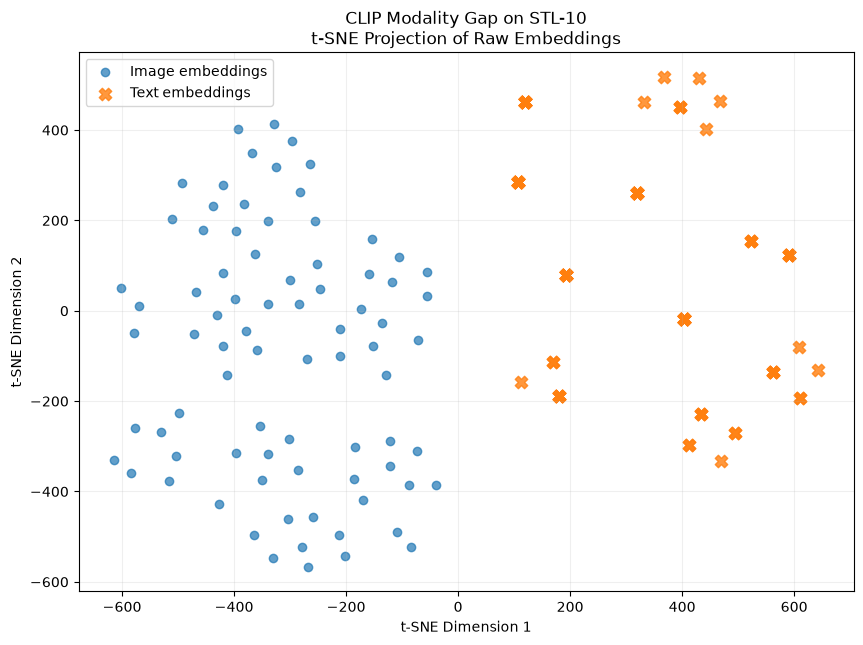

In [22]:
# Visualizes the raw CLIP modality gap.
# Plots image and text embeddings in the same t-SNE space.
plt.figure(figsize=(10, 7))
plt.scatter(raw_image_2d[:, 0], raw_image_2d[:, 1], alpha=0.7, marker="o", label="Image embeddings")
plt.scatter(raw_text_2d[:, 0], raw_text_2d[:, 1], alpha=0.8, marker="X", s=80, label="Text embeddings")
plt.title("CLIP Modality Gap on STL-10\n"
    "t-SNE Projection of Raw Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [23]:
# Runs t-SNE on normalized image and text embeddings.
# Stores the two-dimensional normalized modality projections.
norm_image_2d, norm_text_2d = run_tsne(normalized_image_embeddings,normalized_text_embeddings)
print("Normalized image projection:", norm_image_2d.shape)
print("Normalized text projection :", norm_text_2d.shape)

Normalized image projection: (80, 2)
Normalized text projection : (80, 2)


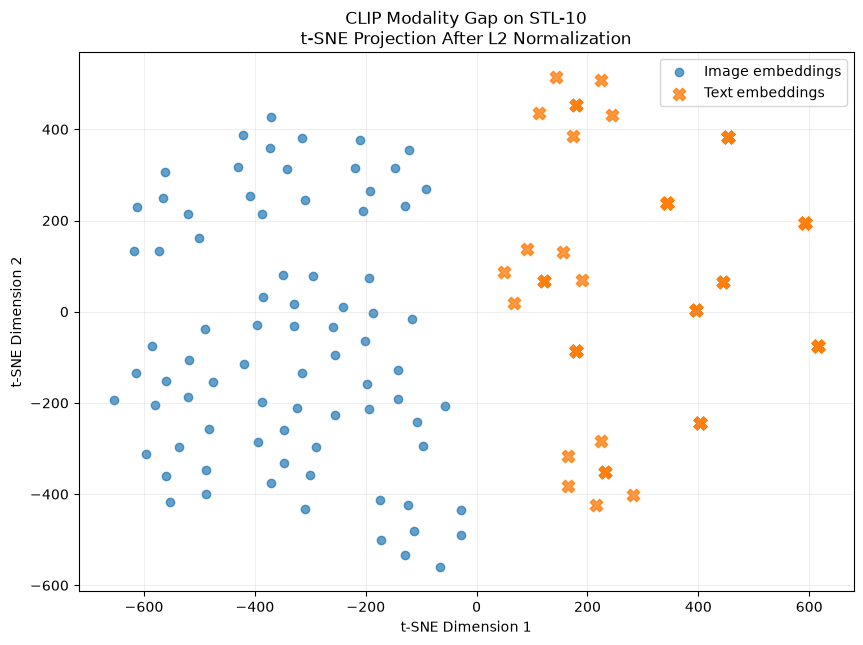

In [24]:
# Visualizes the normalized CLIP modality gap.
# Plots normalized image and text embeddings together.
plt.figure(figsize=(10, 7))
plt.scatter(norm_image_2d[:, 0], norm_image_2d[:, 1], alpha=0.7, marker="o", label="Image embeddings")
plt.scatter(norm_text_2d[:, 0], norm_text_2d[:, 1], alpha=0.8, marker="X", s=80, label="Text embeddings")
plt.title("CLIP Modality Gap on STL-10\n"
    "t-SNE Projection After L2 Normalization")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

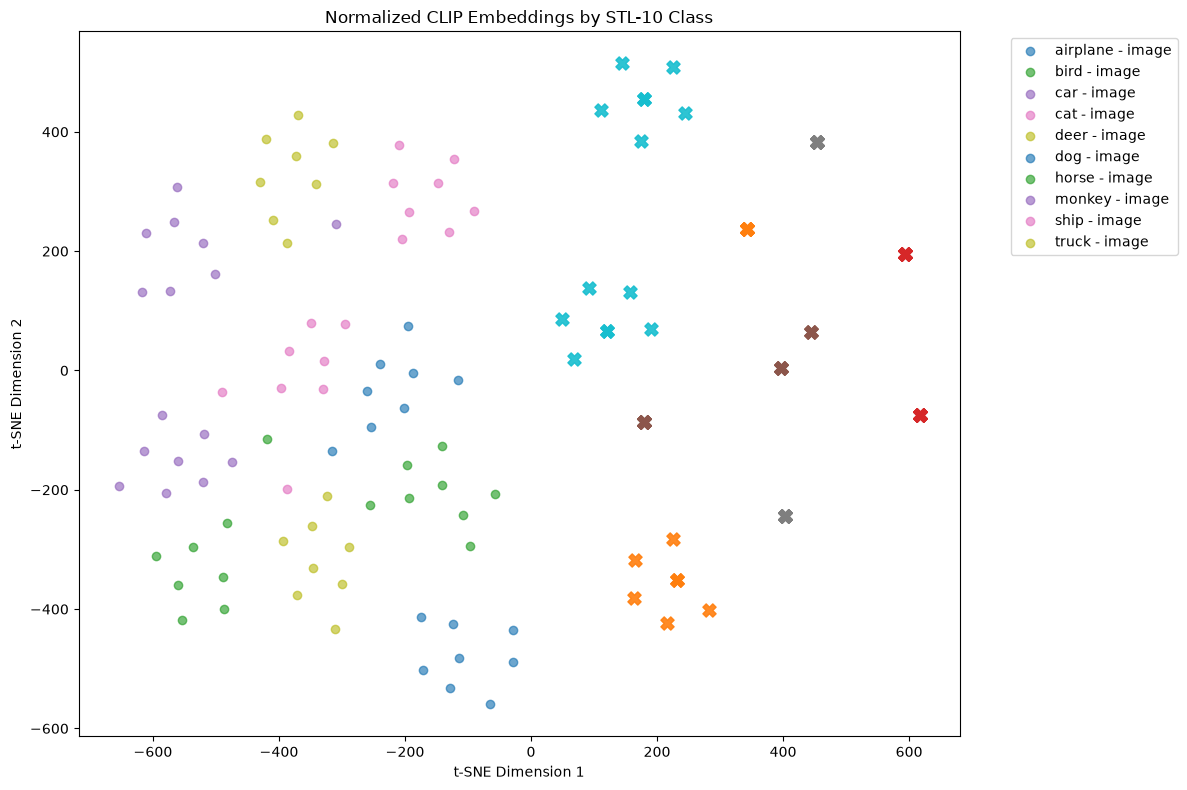

In [25]:
# Creates a class-aware modality visualization.
# Plots normalized embeddings with image and text markers by class.
plt.figure(figsize=(12, 8))
unique_classes = np.unique(sample_labels)

for class_id in unique_classes:
    mask = sample_labels == class_id
    plt.scatter(norm_image_2d[mask, 0], norm_image_2d[mask, 1], marker="o", alpha=0.65, label=f"{class_names[class_id]} - image")
    plt.scatter(norm_text_2d[mask, 0], norm_text_2d[mask, 1], marker="X", s=90, alpha=0.9)

plt.title("Normalized CLIP Embeddings by STL-10 Class")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1),loc="upper left")
plt.tight_layout()
plt.show()

In [26]:
# Computes matched image-text cosine similarity.
# Summarizes alignment quality for paired embeddings.
paired_cosine_similarity = (normalized_image_embeddings * normalized_text_embeddings).sum(dim=1)
print("MATCHED IMAGE-TEXT COSINE SIMILARITY")
print("=" * 55)
print(f"Mean   : {paired_cosine_similarity.mean().item():.4f}")
print(f"Std    : {paired_cosine_similarity.std().item():.4f}")
print(f"Minimum: {paired_cosine_similarity.min().item():.4f}")
print(f"Maximum: {paired_cosine_similarity.max().item():.4f}")

MATCHED IMAGE-TEXT COSINE SIMILARITY
Mean   : 0.2664
Std    : 0.0203
Minimum: 0.2080
Maximum: 0.3069


In [27]:
# Measures centroid separation between modalities.
# Compares raw and normalized image-text centroid distances.
raw_image_centroid = raw_image_embeddings.mean(dim=0)
raw_text_centroid = raw_text_embeddings.mean(dim=0)
raw_centroid_distance = torch.norm(raw_image_centroid - raw_text_centroid).item()
norm_image_centroid = normalized_image_embeddings.mean(dim=0)
norm_text_centroid = normalized_text_embeddings.mean(dim=0)
norm_centroid_distance = torch.norm(norm_image_centroid - norm_text_centroid).item()
print("MODALITY CENTROID DISTANCE")
print("=" * 50)
print(f"Raw embeddings        : {raw_centroid_distance:.4f}")
print(f"Normalized embeddings : {norm_centroid_distance:.4f}")

MODALITY CENTROID DISTANCE
Raw embeddings        : 10.8174
Normalized embeddings : 1.0476


In [28]:
# Computes per-class image-text alignment scores.
# Creates a dataframe of mean cosine similarity by STL-10 class.
class_similarity_results = []

for class_id, class_name in enumerate(class_names):
    mask = sample_labels == class_id
    if mask.sum() == 0:
        continue
    similarities = paired_cosine_similarity[mask]
    class_similarity_results.append({
        "Class": class_name,
        "Samples": int(mask.sum()),
        "Mean Cosine Similarity": similarities.mean().item()})
    
class_similarity_df = pd.DataFrame(class_similarity_results)
class_similarity_df

,Class,Samples,Mean Cosine Similarity
0,airplane,8,0.253687
1,bird,8,0.278592
2,car,8,0.244573
3,cat,8,0.254019
4,deer,8,0.284584
5,dog,8,0.273895
6,horse,8,0.268305
7,monkey,8,0.287152
8,ship,8,0.262830
9,truck,8,0.255878


In [29]:
# Runs zero-shot classification on the modality subset.
# Uses class text embeddings to classify the selected images.
class_prompts = [f"a photo of {'an' if class_name[0].lower() in 'aeiou' else 'a'} {class_name}." for class_name in class_names]

with torch.no_grad(): 
    text_tokens = clip.tokenize(class_prompts).to(device)

with torch.no_grad(): 
    class_text_features = model.encode_text(text_tokens).float()

class_text_features = class_text_features / class_text_features.norm(dim=-1, keepdim=True)
class_text_features = class_text_features.cpu()
similarities = normalized_image_embeddings @ class_text_features.T
predictions = similarities.argmax(dim=1)
subset_accuracy = (predictions.numpy() == sample_labels).mean() * 100

print(
    f"Zero-shot accuracy on the "
    f"{NUM_SAMPLES}-image subset: "
    f"{subset_accuracy:.2f}%")

Zero-shot accuracy on the 80-image subset: 100.00%


In [30]:
# Prints summary statistics for modality-gap discussion.
# Reports norms, centroid distance, cosine similarity, and accuracy.
print("=" * 65)
print("CLIP MODALITY GAP STL-10 SUMMARY")
print(f"\nNumber of samples: {NUM_SAMPLES}")
print(f"Embedding dimension: {raw_image_embeddings.shape[1]}")
print("\n1. RAW EMBEDDING NORMS")
print(f"   Mean image norm: {image_norms.mean():.4f}")
print(f"   Mean text norm: {text_norms.mean():.4f}")
print("\n2. MODALITY CENTROID DISTANCE")
print(f"   Raw: {raw_centroid_distance:.4f}")
print(f"   Normalized: {norm_centroid_distance:.4f}")
print("\n3. MATCHED IMAGE-TEXT ALIGNMENT")
print(f"   Mean cosine similarity: {paired_cosine_similarity.mean().item():.4f}")
print("\n4. ZERO-SHOT PERFORMANCE")
print(f"   Accuracy on subset: {subset_accuracy:.2f}%")


CLIP MODALITY GAP STL-10 SUMMARY

Number of samples: 80
Embedding dimension: 512

1. RAW EMBEDDING NORMS
   Mean image norm: 10.5290
   Mean text norm: 10.1783

2. MODALITY CENTROID DISTANCE
   Raw: 10.8174
   Normalized: 1.0476

3. MATCHED IMAGE-TEXT ALIGNMENT
   Mean cosine similarity: 0.2664

4. ZERO-SHOT PERFORMANCE
   Accuracy on subset: 100.00%


## 3. Bridging the Modality Gap

In [31]:
# Prepares paired matrices for Procrustes alignment.
# Uses normalized image embeddings as X and text embeddings as Y.
X = normalized_image_embeddings.numpy().astype(np.float64)
Y = normalized_text_embeddings.numpy().astype(np.float64)
print("Image embedding matrix X:", X.shape)
print("Text embedding matrix Y :", Y.shape)
assert X.shape == Y.shape, "Image and text embeddings must have the same shape."
print("\nNumber of paired samples :", X.shape[0])
print("Embedding dimension      :", X.shape[1])

Image embedding matrix X: (80, 512)
Text embedding matrix Y : (80, 512)

Number of paired samples : 80
Embedding dimension      : 512


In [32]:
# Learns the orthogonal Procrustes rotation matrix.
# Checks that the learned rotation is approximately orthogonal.
R, procrustes_scale = orthogonal_procrustes(X,Y)
print("Rotation matrix shape:", R.shape)
print("Procrustes scale value:", procrustes_scale)
identity = np.eye(R.shape[0])
orthogonality_error = np.linalg.norm(R.T @ R - identity, ord="fro")
print("Orthogonality error ||R^T R - I||_F:", orthogonality_error)

Rotation matrix shape: (512, 512)
Procrustes scale value: 70.45881775525646
Orthogonality error ||R^T R - I||_F: 3.7893355645745474e-14


In [33]:
# Applies the learned rotation to image embeddings.
# Normalizes aligned image embeddings after transformation.
aligned_image_embeddings_np = X @ R
aligned_image_embeddings = torch.tensor(aligned_image_embeddings_np,dtype=torch.float32)
aligned_image_embeddings = (aligned_image_embeddings / aligned_image_embeddings.norm(dim=-1,keepdim=True))
print("Original image embeddings:", normalized_image_embeddings.shape)
print("Aligned image embeddings:", aligned_image_embeddings.shape)
print("Text embeddings:", normalized_text_embeddings.shape)

Original image embeddings: torch.Size([80, 512])
Aligned image embeddings: torch.Size([80, 512])
Text embeddings: torch.Size([80, 512])


In [34]:
# Computes Procrustes alignment error before and after rotation.
# Reports Frobenius error reduction from the learned transform.
error_before = np.linalg.norm(X - Y, ord="fro")
error_after = np.linalg.norm(X @ R - Y, ord="fro")
improvement = ((error_before - error_after) / error_before) * 100

print("=" * 60)
print(f"PROCRUSTES ALIGNMENT ERROR")
print("=" * 60)
print(f"Before alignment : {error_before:.4f}")
print(f"After alignment  : {error_after:.4f}")
print(f"Reduction        : {improvement:.2f}%")

PROCRUSTES ALIGNMENT ERROR
Before alignment : 10.8344
After alignment  : 4.3683
Reduction        : 59.68%


In [35]:
# Compares matched cosine similarity before and after alignment.
# Reports the average similarity change from Procrustes rotation.
similarity_before = (normalized_image_embeddings * normalized_text_embeddings).sum(dim=1)
similarity_after = (aligned_image_embeddings * normalized_text_embeddings).sum(dim=1)

print("=" * 60)
print("MATCHED IMAGE-TEXT COSINE SIMILARITY")
print("=" * 60)
print(f"Before alignment: {similarity_before.mean().item():.4f}")
print(f"After alignment : {similarity_after.mean().item():.4f}")
difference = (similarity_after.mean() - similarity_before.mean()).item()
print(f"Difference      : {difference:.4f}")

MATCHED IMAGE-TEXT COSINE SIMILARITY
Before alignment: 0.2664
After alignment : 0.8807
Difference      : 0.6144


In [36]:
# Measures centroid gap before and after alignment.
# Compares modality centroid distance after rotating image features.
original_image_centroid = normalized_image_embeddings.mean(dim=0)
aligned_image_centroid = aligned_image_embeddings.mean(dim=0)
text_centroid = normalized_text_embeddings.mean(dim=0)
centroid_gap_before = torch.norm(original_image_centroid - text_centroid).item()
centroid_gap_after = torch.norm(aligned_image_centroid - text_centroid).item()

print("=" * 60)
print("MODALITY CENTROID GAP")
print("=" * 60)
print(f"Before alignment: {centroid_gap_before:.4f}")
print(f"After alignment : {centroid_gap_after:.4f}")
print(f"Gap reduction   : {centroid_gap_before - centroid_gap_after:.4f}")

MODALITY CENTROID GAP
Before alignment: 1.0476
After alignment : 0.1405
Gap reduction   : 0.9070


In [37]:
# Runs joint t-SNE for original, aligned, and text embeddings.
# Creates shared coordinates for before-and-after visualization.
combined_embeddings = torch.cat([normalized_image_embeddings, aligned_image_embeddings, normalized_text_embeddings], dim=0).numpy()
tsne = TSNE(n_components=2, perplexity=25, learning_rate="auto", init="pca", random_state=42, max_iter=1500)
combined_2d = tsne.fit_transform(combined_embeddings)
N = len(normalized_image_embeddings)
original_image_2d = combined_2d[:N]
aligned_image_2d = combined_2d[N:2*N]
text_2d = combined_2d[2*N:]
print("Original image points:", original_image_2d.shape)
print("Aligned image points :", aligned_image_2d.shape)
print("Text points          :", text_2d.shape)

Original image points: (80, 2)
Aligned image points : (80, 2)
Text points          : (80, 2)


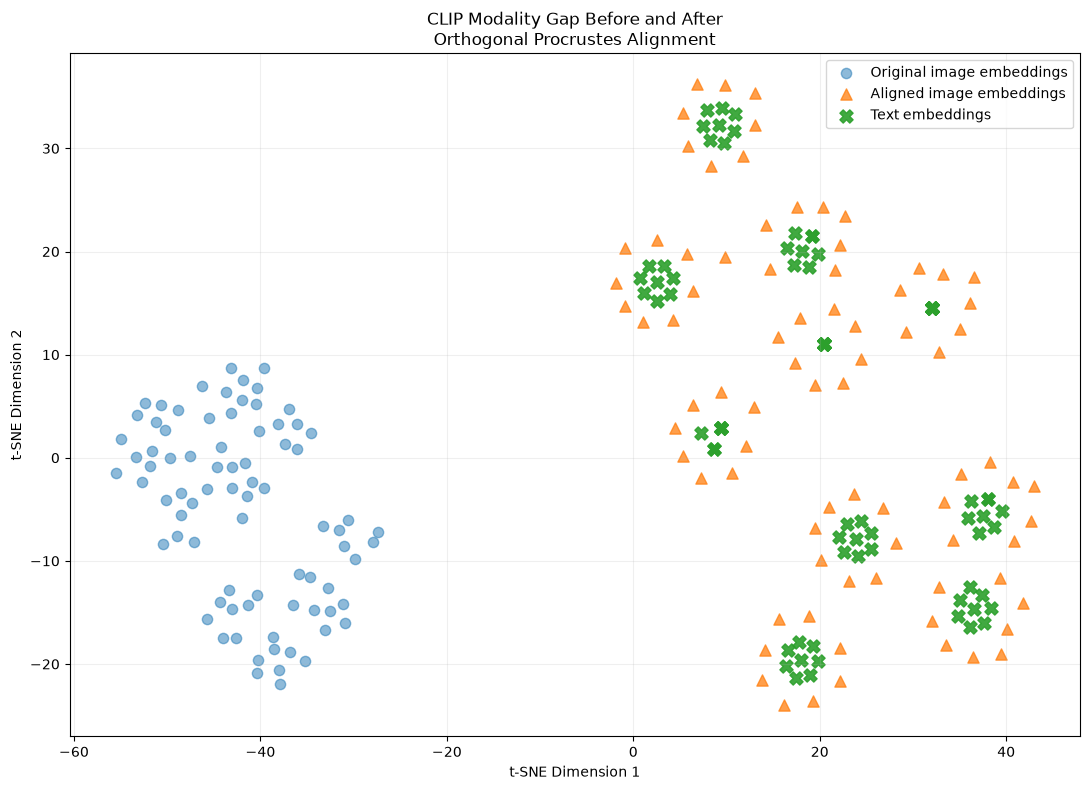

In [ ]:
# Visualizes modality gap before and after Procrustes alignment.
# Plots original images, aligned images, and text embeddings together.
plt.figure(figsize=(11, 8))
plt.scatter(original_image_2d[:, 0], original_image_2d[:, 1], marker="o", alpha=0.5, s=55, label="Original image embeddings")
plt.scatter(aligned_image_2d[:, 0], aligned_image_2d[:, 1], marker="^", alpha=0.75, s=65, label="Aligned image embeddings")
plt.scatter(text_2d[:, 0], text_2d[:, 1], marker="X", alpha=0.9, s=90, label="Text embeddings")
plt.title("CLIP Modality Gap Before and After\n" \
            "Orthogonal Procrustes Alignment")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [39]:
# Applies the learned rotation to the complete STL-10 test set.
# Normalizes the aligned full-test image features.
print("Full STL-10 test embeddings:", image_features.shape)
R_tensor = torch.tensor(R, dtype=image_features.dtype)
aligned_full_image_features = image_features @ R_tensor
aligned_full_image_features = aligned_full_image_features / aligned_full_image_features.norm(dim=-1, keepdim=True)
print("Aligned full test embeddings:", aligned_full_image_features.shape)


Full STL-10 test embeddings: torch.Size([8000, 512])
Aligned full test embeddings: torch.Size([8000, 512])


In [40]:
# Defines classification using a chosen image-embedding matrix.
# Compares image embeddings against CLIP class text embeddings.
def classify_with_embeddings(image_embeddings, true_labels, class_names, strategy):
    text_features = create_text_features(class_names, strategy)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    similarity = image_embeddings @ text_features.T
    predictions = similarity.argmax(dim=1)
    accuracy = (predictions == true_labels).float().mean().item() * 100
    return accuracy, predictions

In [41]:
# Compares original and aligned zero-shot classification.
# Builds a dataframe of accuracy changes for all prompt strategies.
strategies = ["plain","photo","descriptive"]
comparison_results = []

for strategy in strategies:
    original_accuracy, original_predictions = (
        classify_with_embeddings(image_features,true_labels,class_names,strategy))
    aligned_accuracy, aligned_predictions = (classify_with_embeddings(aligned_full_image_features,true_labels,class_names,strategy))
    comparison_results.append({
        "Prompt Strategy": strategy,
        "Original Accuracy (%)": original_accuracy,
        "Aligned Accuracy (%)": aligned_accuracy,
        "Change (%)": aligned_accuracy - original_accuracy})

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,Prompt Strategy,Original Accuracy (%),Aligned Accuracy (%),Change (%)
0,plain,96.262503,95.512497,-0.750005
1,photo,97.312498,96.950001,-0.362498
2,descriptive,94.875002,94.937497,0.062495


In [42]:
# Prints the original versus aligned accuracy comparison.
# Reports percentage-point changes for each prompt strategy.
print("=" * 75)
print("CLIP ZERO-SHOT CLASSIFICATION BEFORE/AFTER PROCRUSTES")
print("=" * 75)

for _, row in comparison_df.iterrows():
    print(f"\nStrategy: {row['Prompt Strategy']}")
    print(f"  Original accuracy : {row['Original Accuracy (%)']:.2f}%")
    print(f"  Aligned accuracy  : {row['Aligned Accuracy (%)']:.2f}%")
    print(f"  Change            : {row['Change (%)']:+.2f} percentage points")

CLIP ZERO-SHOT CLASSIFICATION BEFORE/AFTER PROCRUSTES

Strategy: plain
  Original accuracy : 96.26%
  Aligned accuracy  : 95.51%
  Change            : -0.75 percentage points

Strategy: photo
  Original accuracy : 97.31%
  Aligned accuracy  : 96.95%
  Change            : -0.36 percentage points

Strategy: descriptive
  Original accuracy : 94.88%
  Aligned accuracy  : 94.94%
  Change            : +0.06 percentage points


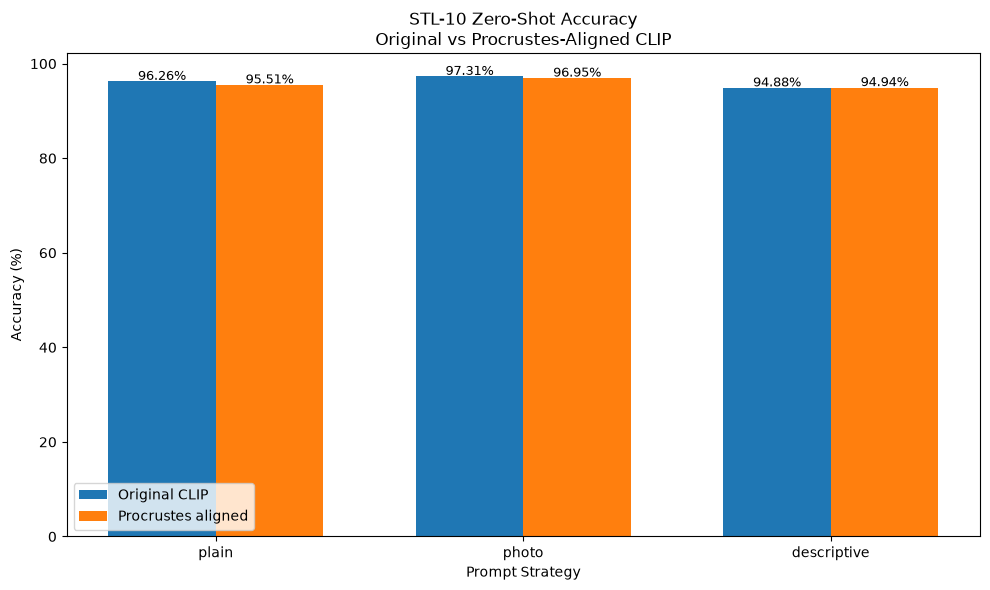

In [43]:
# Plots original versus Procrustes-aligned accuracy.
# Displays side-by-side bars for each prompt strategy.
x = np.arange(len(comparison_df))
width = 0.35
plt.figure(figsize=(10, 6))
bars_original = plt.bar(x - width / 2, comparison_df["Original Accuracy (%)"], width, label="Original CLIP")
bars_aligned = plt.bar(x + width / 2, comparison_df["Aligned Accuracy (%)"], width, label="Procrustes aligned")
plt.xticks(x, comparison_df["Prompt Strategy"])
plt.ylabel("Accuracy (%)")
plt.xlabel("Prompt Strategy")
plt.title("STL-10 Zero-Shot Accuracy\nOriginal vs Procrustes-Aligned CLIP")
plt.legend()

for bars in [bars_original, bars_aligned]:
    for bar in bars:
        value = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, value + 0.3, f"{value:.2f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [44]:
# Creates a held-out evaluation split for alignment testing.
# Excludes the samples used to learn the Procrustes rotation.
all_indices = np.arange(len(true_labels))
alignment_indices = np.array(selected_indices)
held_out_mask = ~np.isin(all_indices, alignment_indices)
held_out_mask = torch.tensor(held_out_mask, dtype=torch.bool)
original_held_out = image_features[held_out_mask]
aligned_held_out = aligned_full_image_features[held_out_mask]
held_out_labels = true_labels[held_out_mask]

print("Alignment samples:", len(selected_indices))
print("Held-out test samples:", len(held_out_labels))

Alignment samples: 80
Held-out test samples: 7920


In [45]:
# Evaluates original and aligned features on held-out samples.
# Stores held-out accuracy results for each prompt strategy.
held_out_results = []

for strategy in strategies:
    original_acc, _ = classify_with_embeddings(original_held_out, held_out_labels, class_names, strategy)
    aligned_acc, _ = classify_with_embeddings(aligned_held_out, held_out_labels, class_names, strategy)
    held_out_results.append({"Prompt Strategy": strategy, "Original Accuracy (%)": original_acc, 
                             "Aligned Accuracy (%)": aligned_acc, "Change (%)": aligned_acc - original_acc})

held_out_df = pd.DataFrame(held_out_results)
held_out_df

,Prompt Strategy,Original Accuracy (%),Aligned Accuracy (%),Change (%)
0,plain,96.249998,95.467174,-0.782824
1,photo,97.285354,96.919191,-0.366163
2,descriptive,94.848484,94.898993,0.050509


In [46]:
# Prints the final Procrustes alignment summary.
# Reports fit quality, modality gap, and classification results.
print("=" * 70)
print("BRIDGING THE CLIP MODALITY GAP")
print("\n1. ALIGNMENT DATA")
print("-" * 40)
print(f"Number of paired embeddings : {X.shape[0]}")
print(f"Embedding dimension         : {X.shape[1]}")
print("\n2. PROCRUSTES FIT")
print("-" * 40)
print(f"Frobenius error before : {error_before:.4f}")
print(f"Frobenius error after  : {error_after:.4f}")
print(f"Error reduction        : {improvement:.2f}%")
print("\n3. IMAGE-TEXT ALIGNMENT")
print("-" * 40)
print(f"Mean cosine before : {similarity_before.mean().item():.4f}")
print(f"Mean cosine after  : {similarity_after.mean().item():.4f}")
print("\n4. MODALITY CENTROID GAP")
print("-" * 40)
print(f"Before alignment : {centroid_gap_before:.4f}")
print(f"After alignment  : {centroid_gap_after:.4f}")
print("\n5. COMPLETE TEST-SET ACCURACY")
print("-" * 40)
print(comparison_df.to_string(index=False))
print("\n6. HELD-OUT TEST ACCURACY")
print("-" * 40)
print(held_out_df.to_string(index=False))

BRIDGING THE CLIP MODALITY GAP

1. ALIGNMENT DATA
----------------------------------------
Number of paired embeddings : 80
Embedding dimension         : 512

2. PROCRUSTES FIT
----------------------------------------
Frobenius error before : 10.8344
Frobenius error after  : 4.3683
Error reduction        : 59.68%

3. IMAGE-TEXT ALIGNMENT
----------------------------------------
Mean cosine before : 0.2664
Mean cosine after  : 0.8807

4. MODALITY CENTROID GAP
----------------------------------------
Before alignment : 1.0476
After alignment  : 0.1405

5. COMPLETE TEST-SET ACCURACY
----------------------------------------
Prompt Strategy  Original Accuracy (%)  Aligned Accuracy (%)  Change (%)
          plain              96.262503             95.512497   -0.750005
          photo              97.312498             96.950001   -0.362498
    descriptive              94.875002             94.937497    0.062495

6. HELD-OUT TEST ACCURACY
----------------------------------------
Prompt Strat